# AIFS Extended Free-Running Forecast: Mid-February to End of May 2026

This notebook:

1. Runs [AIFS](https://huggingface.co/ecmwf/aifs-single-1.1) in **free-running mode** from **2026-02-15 00 UTC** to **2026-05-31 00 UTC** (105 days, 2520 h) on Modal.
2. Evaluates the forecast with the **Anomaly Correlation Coefficient (ACC) for Z500** at **+14 days** (2026-03-01 00 UTC) against the ERA5 analysis.
3. Diagnoses the **Northern-Hemisphere jet-stream latitude** from the AIFS 300 hPa zonal wind over the whole free-run period and compares it with the ERA5 **WMO 1991–2020 climatological normals** for the same calendar period.

Each experiment is isolated in its own icechunk **branch** of the outputs repository, named after the `experiment` variable set in the configuration cell below. Re-running with a different branch name (e.g. a different checkpoint or start date) keeps results completely independent.

In [ ]:
import datetime as dt
import os
import tempfile

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import icechunk
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from aifs_modal_demo import ingest
from aifs_modal_demo.app import app, run_forecast

## Configuration

In [ ]:
# --- experiment label (drives the icechunk branch for outputs) ---
experiment = "jet-stream-feb26"

# --- forecast window ---
start_date = dt.datetime(2026, 2, 15, 0, tzinfo=dt.UTC)
end_date = dt.datetime(2026, 5, 31, 0, tzinfo=dt.UTC)
lead_time = int((end_date - start_date).total_seconds() // 3600)  # hours
print(f"Experiment : {experiment}")
print(f"Start      : {start_date}")
print(f"End        : {end_date}")
print(f"Lead       : {lead_time} h  ({lead_time / 24:.0f} days)")

# --- skill-score reference ---
SKILL_LEAD_DAYS = 14
verification_date = start_date + dt.timedelta(days=SKILL_LEAD_DAYS)
print(f"Verification date (T+{SKILL_LEAD_DAYS}d): {verification_date}")

# --- storage ---
storage_bucket = "aifs-modal"
initial_conditions_prefix = "aifs-initial-conditions"
initial_conditions_branch = "main"
outputs_prefix = "aifs-outputs"
outputs_branch = experiment  # one branch per experiment

Experiment : jet-stream-feb26
Start      : 2026-02-15 00:00:00+00:00
End        : 2026-05-31 00:00:00+00:00
Lead       : 2520 h  (105 days)
Verification date (T+14d): 2026-03-01 00:00:00+00:00


## 1. Ingesting initial conditions

AIFS needs two consecutive analysis states (t−6 h and t) as initial conditions.

In [ ]:
initial_conditions_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=initial_conditions_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
initial_conditions_repo = icechunk.Repository.open(initial_conditions_storage)

for date in [start_date, start_date - dt.timedelta(hours=6)]:
    ingest.ensure_date_ingested(date, initial_conditions_repo)

  2026-03-06T11:11:08.094571Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1771452354651/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121

Initial conditions missing for 2026-02-15T00:00:00+00:00 (group: 2026-02-15/00z); ingesting now


By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


Ingested initial conditions for 2026-02-15T00:00:00+00:00
Initial conditions missing for 2026-02-14T18:00:00+00:00 (group: 2026-02-14/18z); ingesting now


Ingested initial conditions for 2026-02-14T18:00:00+00:00


## 2. Running the extended free-running forecast on Modal

The forecast is written to the branch named after `experiment` (`outputs_branch`). Running this notebook again with a different `experiment` value produces a fully independent branch, leaving previous results untouched.

In [ ]:
# with modal.enable_output():  # uncomment for live logs
with app.run():
    run_forecast.remote(
        start_date,
        storage_bucket,
        lead_time=lead_time,
        outputs_prefix=outputs_prefix,
        outputs_branch=outputs_branch,
        include_pressure_levels=True,  # needed for Z500 and U300
    )

## 3. Loading forecast outputs

In [ ]:
outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
outputs_repo = icechunk.Repository.open(outputs_storage)
outputs_session = outputs_repo.readonly_session(outputs_branch)

forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
forecast_ds = xr.open_dataset(
    outputs_session.store,
    group=forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks="auto",
)
forecast_ds

  2026-03-06T13:47:48.204011Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1771452354651/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 178GB
Dimensions:     (valid_time: 420, lat: 721, lon: 1440, pressure: 13)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2026-02-15T06:00:00 ... 2026-...
  * lat         (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon         (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * pressure    (pressure) int64 104B 50 100 150 200 250 ... 700 850 925 1000
Data variables: (12/30)
    100u        (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    100v        (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    10v         (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    2t          (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    hcc         (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    lcc         (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    ...          ...
    ro          (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    u           (valid_time, pressure, lat, lon) float32 23GB dask.array<chunksize=(2, 13, 721, 1440), meta=np.ndarray>
    v           (valid_time, pressure, lat, lon) float32 23GB dask.array<chunksize=(2, 13, 721, 1440), meta=np.ndarray>
    z           (valid_time, pressure, lat, lon) float32 23GB dask.array<chunksize=(2, 13, 721, 1440), meta=np.ndarray>
    tcc         (valid_time, lat, lon) float32 2GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    w           (valid_time, pressure, lat, lon) float32 23GB dask.array<chunksize=(2, 13, 721, 1440), meta=np.ndarray>

In [ ]:
# quick sanity check: last valid time should be near end of May
print("First valid time:", forecast_ds.valid_time.values[0])
print("Last  valid time:", forecast_ds.valid_time.values[-1])
print("Number of time steps:", forecast_ds.dims["valid_time"])
print("Pressure levels:", forecast_ds.pressure.values)

First valid time: 2026-02-15T06:00:00.000000000
Last  valid time: 2026-05-31T00:00:00.000000000
Number of time steps: 420
Pressure levels: [  50  100  150  200  250  300  400  500  600  700  850  925 1000]


/tmp/ipykernel_2217402/1269242231.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Number of time steps:", forecast_ds.dims["valid_time"])


## 4. Skill score at T+14 days

We evaluate the forecast against the ERA5 analysis at **2026-03-01 00 UTC** using the **Anomaly Correlation Coefficient (ACC)** for **500 hPa geopotential (Z500)**:

$$\text{ACC} = \frac{\sum_i w_i \, f'_i \, a'_i}{\sqrt{\sum_i w_i {f'_i}^2 \cdot \sum_i w_i {a'_i}^2}}$$

where $f'$ (forecast anomaly) and $a'$ (analysis anomaly) are departures from the **ERA5 1991–2020 March monthly climatology**, and $w_i = \cos(\phi_i)$ is the area weight.

### 4.1  ERA5 Z500 analysis for 2026-03-01

Downloaded via the Copernicus CDS API (`~/.cdsapirc` must be configured).

In [ ]:
c = cdsapi.Client()


def _era5_z500_analysis(year, month, day, *, tmp_dir):
    """Download ERA5 Z500 (geopotential, m²/s²) for a specific date."""
    out = os.path.join(tmp_dir, f"era5_z500_{year}_{month:02d}_{day:02d}.nc")
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": "geopotential",
            "pressure_level": "500",
            "year": str(year),
            "month": f"{month:02d}",
            "day": f"{day:02d}",
            "time": "00:00",
            "grid": [0.25, 0.25],
            "area": [90, 0, -90, 360],
            "format": "netcdf",
        },
        out,
    )
    return xr.open_dataset(out)["z"].squeeze()


def _era5_z500_monthly_clim(month, *, tmp_dir):
    """Download ERA5 monthly mean Z500 for 1991–2020 and return the 30-year mean."""
    out = os.path.join(tmp_dir, f"era5_z500_month{month:02d}_clim.nc")
    c.retrieve(
        "reanalysis-era5-pressure-levels-monthly-means",
        {
            "product_type": "monthly_averaged_reanalysis",
            "variable": "geopotential",
            "pressure_level": "500",
            "year": [str(y) for y in range(1991, 2021)],
            "month": f"{month:02d}",
            "time": "00:00",
            "grid": [0.25, 0.25],
            "area": [90, 0, -90, 360],
            "format": "netcdf",
        },
        out,
    )
    return xr.open_dataset(out)["z"].squeeze()


era5_tmp = tempfile.mkdtemp(prefix="era5_")

# ERA5 analysis for the verification date
era5_z500_verif = _era5_z500_analysis(
    verification_date.year,
    verification_date.month,
    verification_date.day,
    tmp_dir=era5_tmp,
)
era5_z500_verif

2026-03-06 14:47:56,228 INFO Request ID is 6328c5d5-9cf8-46fd-9ba4-810054f178bd
2026-03-06 14:47:56,283 INFO status has been updated to accepted
2026-03-06 14:48:09,789 INFO status has been updated to running
2026-03-06 14:48:17,463 INFO status has been updated to successful
                                                                                      

<xarray.DataArray 'z' (latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    valid_time      datetime64[ns] 8B 2026-03-01
    pressure_level  float64 8B 500.0
    expver          <U4 16B ...
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

### 4.2  ERA5 Z500 March climatology (1991–2020)

In [ ]:
era5_z500_clim_march = _era5_z500_monthly_clim(
    verification_date.month,
    tmp_dir=era5_tmp,
).mean("valid_time")  # mean over the 30 years
era5_z500_clim_march

2026-03-06 14:48:18,499 INFO Request ID is 882cd981-9e8e-4123-b07d-a5e9b7bafd23
2026-03-06 14:48:18,539 INFO status has been updated to accepted
2026-03-06 14:48:31,983 INFO status has been updated to successful
                                                                                      

<xarray.DataArray 'z' (latitude: 721, longitude: 1440)> Size: 4MB
array([[49978.207, 49978.207, 49978.207, ..., 49978.207, 49978.207,
        49978.207],
       [49971.332, 49971.332, 49971.332, ..., 49971.293, 49971.3  ,
        49971.31 ],
       [49964.727, 49964.773, 49964.793, ..., 49964.64 , 49964.7  ,
        49964.707],
       ...,
       [48822.566, 48822.582, 48822.59 , ..., 48822.6  , 48822.55 ,
        48822.6  ],
       [48815.883, 48815.86 , 48815.867, ..., 48815.875, 48815.875,
        48815.867],
       [48808.316, 48808.316, 48808.316, ..., 48808.316, 48808.316,
        48808.316]], shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    pressure_level  float64 8B 500.0
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

### 4.3  Compute ACC and RMSE

In [ ]:
# AIFS Z500 at verification time
# `z` has dims (valid_time, pressure, lat, lon)
# valid_time is stored timezone-naive; strip UTC before selecting
aifs_z500 = (
    forecast_ds["z"]
    .sel(
        pressure=500,
        valid_time=verification_date.replace(tzinfo=None),
        method="nearest",
    )
    .load()
)

# align ERA5 grids to AIFS (same 0.25° lat/lon, lon in 0–360)
era5_z500_verif = era5_z500_verif.rename({"latitude": "lat", "longitude": "lon"})
era5_z500_clim_march = era5_z500_clim_march.rename(
    {"latitude": "lat", "longitude": "lon"}
)

# area weights
w = np.cos(np.deg2rad(aifs_z500.lat))

# anomalies
fc_anom = aifs_z500 - era5_z500_clim_march
obs_anom = era5_z500_verif - era5_z500_clim_march
fc_err = aifs_z500 - era5_z500_verif


def weighted_acc(fc_a, obs_a, weights):
    """Compute weighted ACC."""
    num = (weights * fc_a * obs_a).sum(("lat", "lon"))
    denom = np.sqrt(
        (weights * fc_a**2).sum(("lat", "lon"))
        * (weights * obs_a**2).sum(("lat", "lon"))
    )
    return float(num / denom)


def weighted_rmse(err, weights):
    """Compute weighted RMSE."""
    return float(np.sqrt((weights * err**2).sum(("lat", "lon")) / weights.sum()))


acc_global = weighted_acc(fc_anom, obs_anom, w)
acc_nh = weighted_acc(
    fc_anom.sel(lat=slice(90, 20)),
    obs_anom.sel(lat=slice(90, 20)),
    w.sel(lat=slice(90, 20)),
)
rmse_global = weighted_rmse(fc_err, w)
rmse_nh = weighted_rmse(fc_err.sel(lat=slice(90, 20)), w.sel(lat=slice(90, 20)))

print(f"Z500 skill at T+{SKILL_LEAD_DAYS}d ({verification_date:%Y-%m-%d})")
print(f"  ACC  (global) : {acc_global:.3f}")
print(f"  ACC  (NH ext) : {acc_nh:.3f}")
print(f"  RMSE (global) : {rmse_global:.1f} m²/s²")
print(f"  RMSE (NH ext) : {rmse_nh:.1f} m²/s²")

Z500 skill at T+14d (2026-03-01)
  ACC  (global) : 0.219
  ACC  (NH ext) : 0.314
  RMSE (global) : 40982.4 m²/s²
  RMSE (NH ext) : 52016.5 m²/s²


### 4.4  Spatial Z500 error map

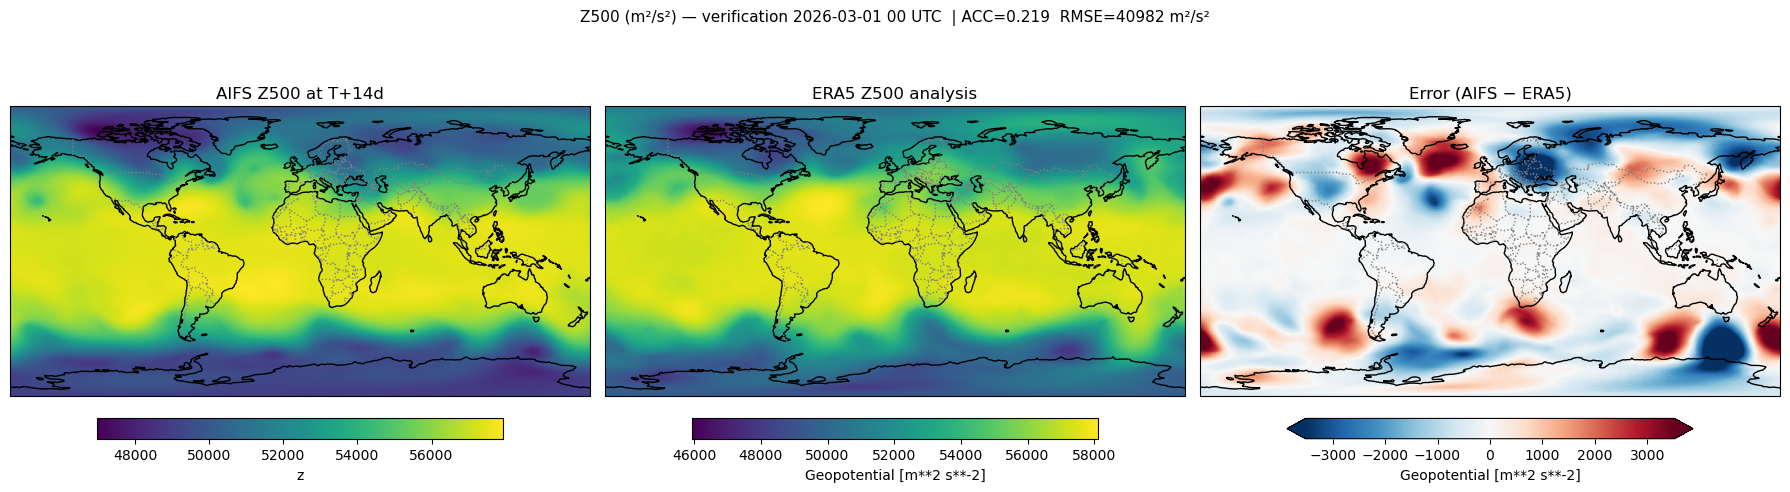

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    subplot_kw={
        "projection": __import__("cartopy.crs", fromlist=["PlateCarree"]).PlateCarree()
    },
)

titles = [
    f"AIFS Z500 at T+{SKILL_LEAD_DAYS}d",
    "ERA5 Z500 analysis",
    "Error (AIFS − ERA5)",
]
fields = [aifs_z500, era5_z500_verif, fc_err]
cmaps = ["viridis", "viridis", "RdBu_r"]

for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
    vmax = float(np.abs(field).quantile(0.98)) if "Error" in title else None
    vkw = dict(vmin=-vmax, vmax=vmax) if "Error" in title else {}
    field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"shrink": 0.7, "orientation": "horizontal", "pad": 0.05},
        **vkw,
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="grey")
    ax.set_title(title)

fig.suptitle(
    f"Z500 (m²/s²) — verification {verification_date:%Y-%m-%d 00 UTC}  "
    f"| ACC={acc_global:.3f}  RMSE={rmse_global:.0f} m²/s²",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. Jet-stream latitude analysis

The NH jet-stream latitude at each time step is defined as the **latitude of the maximum zonal-mean 300 hPa zonal wind** (U300) between 20°N and 80°N:

$$\phi_{\text{jet}}(t) = \arg\max_{\phi \in [20°N,\,80°N]} \overline{u}_{300}(\phi, t)$$

We compare the AIFS free-run jet latitude with the **ERA5 1991–2020 monthly climatological jet latitude** for the same calendar period.

### 5.1  AIFS jet-stream latitude time series

In [ ]:
# U300 from AIFS: dims (valid_time, pressure, lat, lon)
u300_aifs = forecast_ds["u"].sel(pressure=300, lat=slice(80, 20)).mean("lon").load()

# latitude of maximum zonal-mean U at each time step
jet_lat_aifs = u300_aifs.idxmax("lat").rename("jet_lat_aifs")

# also compute a 5-day (20-step) running mean for readability
jet_lat_aifs_rm = jet_lat_aifs.rolling(valid_time=20, center=True, min_periods=1).mean()

print("AIFS jet latitude — summary:")
print(f"  Mean : {float(jet_lat_aifs.mean()):.1f}°N")
print(f"  Std  : {float(jet_lat_aifs.std()):.1f}°")
print(f"  Min  : {float(jet_lat_aifs.min()):.1f}°N")
print(f"  Max  : {float(jet_lat_aifs.max()):.1f}°N")

AIFS jet latitude — summary:
  Mean : 34.0°N
  Std  : 8.6°
  Min  : 21.0°N
  Max  : 52.8°N


### 5.2  ERA5 1991–2020 climatological jet latitude

We download ERA5 **monthly mean U300** for February through May averaged over 1991–2020, then compute the monthly jet latitude.

In [ ]:
def _era5_u300_monthly_clim(month, *, tmp_dir):
    """Download ERA5 monthly U300 mean for 1991–2020 and return the 30-yr mean."""
    out = os.path.join(tmp_dir, f"era5_u300_month{month:02d}_clim.nc")
    c.retrieve(
        "reanalysis-era5-pressure-levels-monthly-means",
        {
            "product_type": "monthly_averaged_reanalysis",
            "variable": "u_component_of_wind",
            "pressure_level": "300",
            "year": [str(y) for y in range(1991, 2021)],
            "month": f"{month:02d}",
            "time": "00:00",
            "grid": [0.25, 0.25],
            "area": [80, 0, 20, 360],  # NH jet region only
            "format": "netcdf",
        },
        out,
    )
    ds = xr.open_dataset(out)
    # variable name may be 'u' or 'u_component_of_wind' depending on CDS version
    u = ds[[v for v in ds if "u" in v.lower()][0]].squeeze()
    # 30-year mean, then zonal mean
    return u.mean("valid_time").mean("longitude")


# months covered by the free run: February (partial) through May
clim_months = [2, 3, 4, 5]
clim_jet_lats = {}

for m in clim_months:
    u300_clim = _era5_u300_monthly_clim(m, tmp_dir=era5_tmp)
    # latitude of max zonal-mean U300 (lat coord name from CDS is 'latitude')
    lat_dim = "latitude" if "latitude" in u300_clim.dims else "lat"
    clim_jet_lats[m] = float(u300_clim.idxmax(lat_dim))
    print(f"Month {m:2d}: climatological jet latitude = {clim_jet_lats[m]:.1f}°N")

2026-03-06 14:53:31,782 INFO Request ID is 6a386592-60ca-4d76-9572-375dcd6b0cb8
2026-03-06 14:53:31,841 INFO status has been updated to accepted
2026-03-06 14:59:50,891 INFO status has been updated to successful
2026-03-06 14:59:52,778 INFO Request ID is c05a6600-613c-4354-9cd6-b1c542db6055       
2026-03-06 14:59:52,830 INFO status has been updated to accepted


Month  2: climatological jet latitude = 29.0°N


2026-03-06 15:00:06,261 INFO status has been updated to running
2026-03-06 15:00:25,338 INFO status has been updated to successful
2026-03-06 15:00:27,409 INFO Request ID is 66339a09-b7f3-4b0d-8569-75c7d6e6f81b       


Month  3: climatological jet latitude = 27.8°N


2026-03-06 15:00:27,457 INFO status has been updated to accepted
2026-03-06 15:00:35,905 INFO status has been updated to running
2026-03-06 15:01:00,206 INFO status has been updated to successful
2026-03-06 15:01:01,976 INFO Request ID is 793d194d-32a3-4fa2-bb12-69f2cce1ad64       


Month  4: climatological jet latitude = 35.2°N


2026-03-06 15:01:02,202 INFO status has been updated to accepted
2026-03-06 15:01:15,602 INFO status has been updated to running
2026-03-06 15:01:23,261 INFO status has been updated to successful
                                                                                      

Month  5: climatological jet latitude = 37.8°N


### 5.3  Comparison: AIFS free-run vs. ERA5 1991–2020 climatology

/home/martibosch/data-science/aifs-modal-demo/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


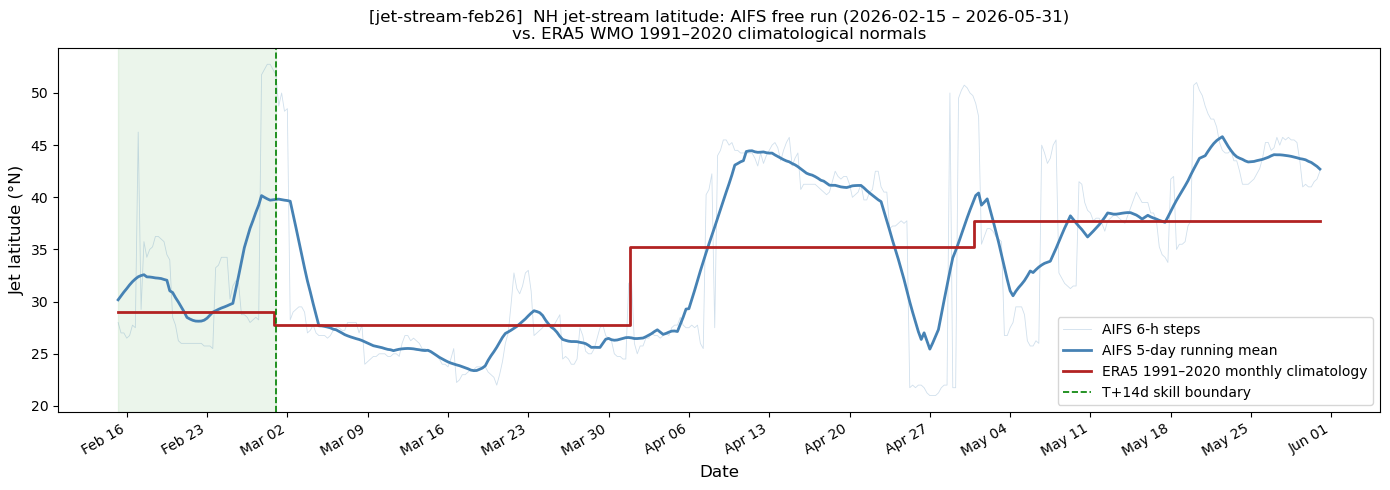

In [ ]:
valid_times = jet_lat_aifs.valid_time.values  # numpy datetime64
times_pd = pd.DatetimeIndex(valid_times)

# map each valid time to the monthly climatological jet latitude
clim_ts = np.array([clim_jet_lats[ts.month] for ts in times_pd])

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    times_pd,
    jet_lat_aifs.values,
    color="steelblue",
    alpha=0.25,
    linewidth=0.6,
    label="AIFS 6-h steps",
)
ax.plot(
    times_pd,
    jet_lat_aifs_rm.values,
    color="steelblue",
    linewidth=2,
    label="AIFS 5-day running mean",
)
ax.step(
    times_pd,
    clim_ts,
    color="firebrick",
    linewidth=2,
    where="mid",
    label="ERA5 1991–2020 monthly climatology",
)

ax.axvspan(
    times_pd[0],
    pd.Timestamp(verification_date),
    alpha=0.08,
    color="green",
)
ax.axvline(
    pd.Timestamp(verification_date),
    color="green",
    linestyle="--",
    linewidth=1.2,
    label=f"T+{SKILL_LEAD_DAYS}d skill boundary",
)

ax.set_ylabel("Jet latitude (°N)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title(
    f"[{experiment}]  NH jet-stream latitude: AIFS free run "
    f"({start_date:%Y-%m-%d} – {end_date:%Y-%m-%d})\n"
    "vs. ERA5 WMO 1991–2020 climatological normals",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame(
    {
        "valid_time": times_pd,
        "month": times_pd.month,
        "aifs_jet_lat": jet_lat_aifs.values,
        "era5_clim_lat": clim_ts,
    }
)
df["bias"] = df["aifs_jet_lat"] - df["era5_clim_lat"]

monthly_summary = (
    df.groupby("month")
    .agg(
        aifs_mean=("aifs_jet_lat", "mean"),
        aifs_std=("aifs_jet_lat", "std"),
        era5_clim=("era5_clim_lat", "first"),
        bias=("bias", "mean"),
    )
    .rename(index={2: "Feb", 3: "Mar", 4: "Apr", 5: "May"})
)

print(f"[{experiment}]  monthly jet-latitude summary")
print(monthly_summary.round(1).to_string())

[jet-stream-feb26]  monthly jet-latitude summary
       aifs_mean  aifs_std  era5_clim  bias
month                                      
Feb         32.1       7.7       29.0   3.1
Mar         27.1       5.1       27.8  -0.6
Apr         36.4       9.1       35.2   1.2
May         39.3       6.1       37.8   1.6
